In [1]:
import pandas as pd

from lightgbm import LGBMRegressor
import lightgbm as lgb

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

In [2]:
!ls ../data/datasets/daily/

dataset_level_01_daily_total.parquet
dataset_level_02_daily_state.parquet
dataset_level_03_daily_cat.parquet
dataset_level_04_daily_dept.parquet
dataset_level_05_daily_state_cat.parquet
dataset_level_06_daily_store.parquet
dataset_level_07_daily_state_dept.parquet
dataset_level_08_daily_store_cat.parquet
dataset_level_09_daily_store_dept.parquet
dataset_level_10_daily_item__FOODS_1.parquet
dataset_level_10_daily_item__FOODS_2.parquet
dataset_level_10_daily_item__FOODS_3.parquet
dataset_level_10_daily_item__HOBBIES_1.parquet
dataset_level_10_daily_item__HOBBIES_2.parquet
dataset_level_10_daily_item__HOUSEHOLD_1.parquet
dataset_level_10_daily_item__HOUSEHOLD_2.parquet
dataset_level_11_daily_item_state__CA_FOODS_1.parquet
dataset_level_11_daily_item_state__CA_FOODS_2.parquet
dataset_level_11_daily_item_state__CA_FOODS_3.parquet
dataset_level_11_daily_item_state__CA_HOBBIES_1.parquet
dataset_level_11_daily_item_state__CA_HOBBIES_2.parquet
dataset_level_11_daily_item_state__CA_HOUSEHOLD_1.p

# Config

In [3]:
#Entrada
LEVEL = 'level_09_daily_store_dept'
GRAIN = 'daily'

#Modelo
OBJECTIVE = "rmse"

#Permutacion (features)
SAMPLE_SIZE_IMP_PERM = 300_000
N_REPEATS_IMP_PERM = 5
TOLERANCE_PERMUTATION = 0.0

#Explainer
SAMPLE_SIZE_EXPLAINER = 300_000

#Optimizado
TIEMPO_OPTUNA = 60 * 3
FINAL_ESTIMATORS = 5_000

# Ventanas modelos Naive
SN_WINDOWS = {"daily": [1, 7, 28, 364], "weekly": [1, 4, 52]}[GRAIN]
MA_WINDOWS = {"daily": [7, 14, 21, 28, 35], "weekly": [2, 3, 4, 6, 8,]}[GRAIN]

In [4]:
import config

DATASET_PATH = f'../data/datasets/{GRAIN}/dataset_{LEVEL}.parquet'

SEASON_LENGTH = config.SEASON_LENGTH[GRAIN]
VALID_DAYS = config.valid_year_days(GRAIN)
TEST_DAYS = config.test_days(GRAIN)

# Data

In [5]:
df = pd.read_parquet(DATASET_PATH)
df = df.sort_values(['series_id', 'date'])

df.head()

,series_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum364,price_vs_max,days_since_release,days_since_event,days_to_event,days_to_closure,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,is_store_closed,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,price_volatility,days_since_thanksgiving,days_to_thanksgiving,days_since_newyear,days_to_newyear,zero_streak,pct_zero_28,pct_zero_90,adi_expanding,cv2_90,is_likely_stockout,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15,lag16,lag17,lag18,lag19,lag20,lag21,lag22,lag23,lag24,lag25,lag26,lag27,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag1_window_size7,rolling_std_lag1_window_size7,rolling_min_lag1_window_size7,rolling_max_lag1_window_size7,rolling_mean_lag1_window_size14,rolling_std_lag1_window_size14,rolling_min_lag1_window_size14,rolling_max_lag1_window_size14,rolling_mean_lag1_window_size21,rolling_std_lag1_window_size21,rolling_min_lag1_window_size21,rolling_max_lag1_window_size21,rolling_mean_lag1_window_size35,rolling_std_lag1_window_size35,rolling_min_lag1_window_size35,rolling_max_lag1_window_size35,rolling_mean_lag1_window_size7_truediv_rolling_mean_lag1_window_size35,rolling_mean_lag2_window_size7,rolling_std_lag2_window_size7,rolling_min_lag2_window_size7,rolling_max_lag2_window_size7,rolling_mean_lag2_window_size14,rolling_std_lag2_window_size14,rolling_min_lag2_window_size14,rolling_max_lag2_window_size14,rolling_mean_lag3_window_size7,rolling_std_lag3_window_size7,rolling_min_lag3_window_size7,rolling_max_lag3_window_size7,rolling_mean_lag3_window_size14,rolling_std_lag3_window_size14,rolling_min_lag3_window_size14,rolling_max_lag3_window_size14,rolling_mean_lag4_window_size7,rolling_std_lag4_window_size7,rolling_min_lag4_window_size7,rolling_max_lag4_window_size7,rolling_mean_lag4_window_size14,rolling_std_lag4_window_size14,rolling_min_lag4_window_size14,rolling_max_lag4_window_size14,rolling_mean_lag5_window_size7,rolling_std_lag5_window_size7,rolling_min_lag5_window_size7,rolling_max_lag5_window_size7,rolling_mean_lag5_window_size14,rolling_std_lag5_window_size14,rolling_min_lag5_window_size14,rolling_max_lag5_window_size14,rolling_mean_lag6_window_size7,rolling_std_lag6_window_size7,rolling_min_lag6_window_size7,rolling_max_lag6_window_size7,rolling_mean_lag6_window_size14,rolling_std_lag6_window_size14,rolling_min_lag6_window_size14,rolling_max_lag6_window_size14,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_mean_lag364_window_size91
0,FOODS_1_FOODS_CA_1_CA,TOTAL,FOODS_1,FOODS,CA_1,CA,2011-01-29,297.0,681.179993,2.293535,NaN,NaN,0.991603,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,6,4,1,1533.0,3305.0,5047.0,6652.0,8373.0,10069.0,75674.0,1.000000,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.000000,0.46325

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 135870 entries, 0 to 135869
Columns: 184 entries, series_id to rolling_mean_lag364_window_size91
dtypes: category(10), datetime64[ms](1), float32(156), int16(1), int32(1), int8(15)
memory usage: 85.9 MB


# Variables

In [7]:
TARGET = "sales"

ID_COLS = ["series_id", "date"]
CUM_COLS = [c for c in df.columns if c.startswith("cum") and c[3:].isdigit()]
LEAKY_COLS = ["gross_sales"] + CUM_COLS

FEATURES = [c for c in df.columns if c not in ID_COLS + LEAKY_COLS + [TARGET]]

CATEGORICAL_FEATURES = [
    c for c in [
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
    ] if c in df.columns
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

print(len(FEATURES), "features disponibles")

173 features disponibles


# Split

In [8]:
from src.data import date_split

data_split = date_split(df, valid_days=VALID_DAYS, test_days=TEST_DAYS)

train, valid, test = data_split.train, data_split.valid, data_split.test
first_date, last_date = data_split.first_date, data_split.last_date
valid_start, test_start = data_split.valid_start, data_split.test_start

data_split.log_summary()

2026-08-24 00:11:19.306 | INFO     | src.data.split:log_summary:46 - Train : 2011-01-29 to 2015-04-26 (1,549 days, 108,430 rows)
2026-08-24 00:11:19.307 | INFO     | src.data.split:log_summary:47 - Valid : 2015-04-27 to 2016-04-24 (364 days, 25,480 rows)
2026-08-24 00:11:19.308 | INFO     | src.data.split:log_summary:48 - Test  : 2016-04-25 to 2016-05-22 (28 days, 1,960 rows)


In [9]:
import gc
from src.data import build_feature_matrices

X_train, y_train, X_valid, y_valid, X_test, y_test = build_feature_matrices(
    df, data_split, FEATURES, CATEGORICAL_FEATURES, TARGET, GRAIN,
)

eval_cols = [c for c in ["series_id", "date", "sales", "gross_sales", "avg_sell_price", "is_store_closed"]
             if c in df.columns]
train = train[eval_cols].copy()
valid = valid[eval_cols].copy()
test = test[eval_cols].copy()

del df, data_split
gc.collect()

print(f"Cantidad features: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categoricas)")

Cantidad features: 173 (9 categoricas)


# Comparación de modelos

Antes de invertir tiempo en selección de features, se evalúan varios modelos con hiperparámetros por defecto sobre el set de validación. El objetivo es elegir la familia de modelo con mejor desempeño (WAPE/WRMSSE) para después iterar sobre ella (feature selection, tuning, etc.).

In [10]:
import time
from src.evaluation import evaluate_predictions

model_results = []
predictions_valid = {}

def evaluate_model(name, y_pred_valid, fit_time=None, category=None):
    result = evaluate_predictions(train, valid, y_valid, y_pred_valid, name, fit_time=fit_time, category=category)
    model_results.append(result)
    predictions_valid[name] = y_pred_valid
    return result

## Baseline models

In [11]:
from src.modeling import seasonal_naive, drift, historical_mean, moving_average

In [12]:
for window in SN_WINDOWS:
    t0 = time.perf_counter()
    y_pred_sn= seasonal_naive(train, valid, TARGET, season_length=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Naive ({window}{GRAIN[0]})", y_pred_sn, fit_time=fit_time, category="Naive")

2026-08-24 00:11:19.791 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -        Naive (1d) [Naive] | WAPE: 26.44% | WRMSSE: 1.5142 | MAE: 148.836 | RMSE: 263.396 | SMAPE: 27.85% | Bias: 9.83% | RMSLE: 0.3802 | TS: -9477.97 | SPEC: 303406.346 | MASE: 1.7361 | fit: 0.06s
2026-08-24 00:11:19.968 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -        Naive (7d) [Naive] | WAPE: 19.03% | WRMSSE: 1.0971 | MAE: 107.123 | RMSE: 204.572 | SMAPE: 23.60% | Bias: -11.14% | RMSLE: 0.3508 | TS: 14916.58 | SPEC: 278946.613 | MASE: 1.1753 | fit: 0.05s
2026-08-24 00:11:20.148 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -       Naive (28d) [Naive] | WAPE: 19.70% | WRMSSE: 1.1511 | MAE: 110.923 | RMSE: 203.010 | SMAPE: 24.01% | Bias: -6.54% | RMSLE: 0.3506 | TS: 8460.46 | SPEC: 151421.568 | MASE: 1.2341 | fit: 0.06s
2026-08-24 00:11:20.339 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -      Naive (364d) [Naive] | WAPE: 19.25% | WRMSSE: 1.1647 |

### Drift

In [13]:
t0 = time.perf_counter()
y_pred_drift = drift(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Drift", y_pred_drift, fit_time=fit_time, category="Naive")

2026-08-24 00:11:20.491 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -             Drift [Naive] | WAPE: 28.80% | WRMSSE: 1.6565 | MAE: 162.139 | RMSE: 285.478 | SMAPE: 29.68% | Bias: 13.04% | RMSLE: 0.4062 | TS: -11541.78 | SPEC: 354715.507 | MASE: 1.9170 | fit: 0.02s


{'model': 'Drift',
 'category': 'Naive',
 'wape': 0.2879810479116899,
 'wrmsse': 1.6564626521806611,
 'mae': 162.13864202657805,
 'rmse': 285.4782163471741,
 'smape': 0.29682290123914146,
 'bias': 0.1304479775447261,
 'rmsle': 0.4062329265371146,
 'tracking_signal': -11541.78197469049,
 'spec': 354715.50696000055,
 'mase': 1.9170342389162476,
 'fit_time': 0.020700635999673977}

### Historical mean

In [14]:
t0 = time.perf_counter()
y_pred_mean = historical_mean(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Historical mean", y_pred_mean, fit_time=fit_time, category="Naive")

2026-08-24 00:11:20.650 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -   Historical mean [Naive] | WAPE: 24.43% | WRMSSE: 1.5380 | MAE: 137.545 | RMSE: 236.156 | SMAPE: 29.99% | Bias: -16.12% | RMSLE: 0.4005 | TS: 16810.50 | SPEC: 554410.846 | MASE: 1.6909 | fit: 0.01s


{'model': 'Historical mean',
 'category': 'Naive',
 'wape': 0.24429891703100265,
 'wrmsse': 1.5379935517774888,
 'mae': 137.54479658715954,
 'rmse': 236.15598599027837,
 'smape': 0.29986493966993116,
 'bias': -0.1611768612527026,
 'rmsle': 0.40048817572505335,
 'tracking_signal': 16810.497871333962,
 'spec': 554410.8461521929,
 'mase': 1.690930383913674,
 'fit_time': 0.005894896996323951}

### Moving average

In [15]:
for window in MA_WINDOWS:
    t0 = time.perf_counter()
    y_pred_ma = moving_average(train, valid, TARGET, window=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Moving average ({window}{GRAIN[0]})", y_pred_ma, fit_time=fit_time, category="Naive")

2026-08-24 00:11:20.807 | INFO     | src.evaluation.metrics:evaluate_predictions:359 - Moving average (7d) [Naive] | WAPE: 21.18% | WRMSSE: 1.2579 | MAE: 119.261 | RMSE: 228.791 | SMAPE: 23.80% | Bias: -11.14% | RMSLE: 0.3420 | TS: 13404.24 | SPEC: 276441.690 | MASE: 1.3328 | fit: 0.01s
2026-08-24 00:11:20.951 | INFO     | src.evaluation.metrics:evaluate_predictions:359 - Moving average (14d) [Naive] | WAPE: 20.58% | WRMSSE: 1.2318 | MAE: 115.886 | RMSE: 218.605 | SMAPE: 23.33% | Bias: -9.64% | RMSLE: 0.3378 | TS: 11929.98 | SPEC: 202938.878 | MASE: 1.3044 | fit: 0.01s
2026-08-24 00:11:21.095 | INFO     | src.evaluation.metrics:evaluate_predictions:359 - Moving average (21d) [Naive] | WAPE: 20.20% | WRMSSE: 1.1997 | MAE: 113.718 | RMSE: 213.362 | SMAPE: 22.82% | Bias: -7.46% | RMSLE: 0.3292 | TS: 9415.53 | SPEC: 160233.787 | MASE: 1.2810 | fit: 0.01s
2026-08-24 00:11:21.241 | INFO     | src.evaluation.metrics:evaluate_predictions:359 - Moving average (28d) [Naive] | WAPE: 20.19% | WRMS

## Modelos estadísticos clásicos

Familias de forecasting estadístico clásico, ajustadas serie por serie (sin usar la matriz de features de ML). SARIMA es el modelo más citado en la literatura académica; ETS/Holt-Winters es rápido y robusto (base de benchmarks M4/M5); Theta ganó la M3 pese a su simplicidad; TBATS extiende ETS para estacionalidades múltiples; Prophet (Meta) es popular en industria por ser fácil de tunear.

In [16]:
from src.modeling import fit_sarima, fit_ets, fit_theta, fit_tbats, fit_prophet

### SARIMA

In [17]:
t0 = time.perf_counter()
y_pred_sarima = fit_sarima(train, valid, TARGET, seasonal_order=(1, 1, 1, SEASON_LENGTH))
fit_time = time.perf_counter() - t0

evaluate_model("SARIMA", y_pred_sarima, fit_time=fit_time, category="Statistical")

2026-08-24 00:11:26.945 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -      SARIMA [Statistical] | WAPE: 23.39% | WRMSSE: 1.2939 | MAE: 131.705 | RMSE: 262.163 | SMAPE: 27.16% | Bias: -12.60% | RMSLE: 0.4073 | TS: 13729.16 | SPEC: 552745.523 | MASE: 1.4346 | fit: 5.38s


{'model': 'SARIMA',
 'category': 'Statistical',
 'wape': 0.2339258912684974,
 'wrmsse': 1.2939053214334446,
 'mae': 131.70459174369685,
 'rmse': 262.16299657581754,
 'smape': 0.2716004395684901,
 'bias': -0.12604414562976882,
 'rmsle': 0.40727392041681637,
 'tracking_signal': 13729.155046630845,
 'spec': 552745.52301955,
 'mase': 1.434572968843325,
 'fit_time': 5.376663521004957}

### ETS (Holt-Winters)

In [18]:
t0 = time.perf_counter()
y_pred_ets = fit_ets(train, valid, TARGET, seasonal_periods=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("ETS (Holt-Winters)", y_pred_ets, fit_time=fit_time, category="Statistical")

2026-08-24 00:11:28.402 | INFO     | src.evaluation.metrics:evaluate_predictions:359 - ETS (Holt-Winters) [Statistical] | WAPE: 17.77% | WRMSSE: 1.0110 | MAE: 100.073 | RMSE: 197.225 | SMAPE: 21.52% | Bias: -7.49% | RMSLE: 0.3329 | TS: 10742.18 | SPEC: 247208.262 | MASE: 1.0831 | fit: 1.32s


{'model': 'ETS (Holt-Winters)',
 'category': 'Statistical',
 'wape': 0.17774335054141413,
 'wrmsse': 1.0109668397597478,
 'mae': 100.07278498019899,
 'rmse': 197.22532735499152,
 'smape': 0.2152005792858099,
 'bias': -0.07493528051535832,
 'rmsle': 0.33289433309869076,
 'tracking_signal': 10742.179337316205,
 'spec': 247208.26193797027,
 'mase': 1.083067990924655,
 'fit_time': 1.3152830620019813}

### Theta

In [19]:
t0 = time.perf_counter()
y_pred_theta = fit_theta(train, valid, TARGET, period=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("Theta", y_pred_theta, fit_time=fit_time, category="Statistical")

2026-08-24 00:11:28.724 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -       Theta [Statistical] | WAPE: 17.49% | WRMSSE: 0.9991 | MAE: 98.468 | RMSE: 192.759 | SMAPE: 21.08% | Bias: -7.85% | RMSLE: 0.3219 | TS: 11442.57 | SPEC: 232797.059 | MASE: 1.0664 | fit: 0.18s


{'model': 'Theta',
 'category': 'Statistical',
 'wape': 0.17489282074245852,
 'wrmsse': 0.9991446323019675,
 'mae': 98.46788412297074,
 'rmse': 192.75870709510488,
 'smape': 0.21081142926581775,
 'bias': -0.07854097274076557,
 'rmsle': 0.32188478422602074,
 'tracking_signal': 11442.573668484907,
 'spec': 232797.05855654716,
 'mase': 1.066410698990295,
 'fit_time': 0.17540232300234493}

### TBATS

In [20]:
t0 = time.perf_counter()
y_pred_tbats = fit_tbats(train, valid, TARGET, season_length=(SEASON_LENGTH,))
fit_time = time.perf_counter() - t0

evaluate_model("TBATS", y_pred_tbats, fit_time=fit_time, category="Statistical")

/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or neg

{'model': 'TBATS',
 'category': 'Statistical',
 'wape': 0.23764633727077347,
 'wrmsse': 1.3179252440910094,
 'mae': 133.7992714697295,
 'rmse': 264.6495066978404,
 'smape': 0.2861699305837469,
 'bias': -0.10935938292464198,
 'rmsle': 0.5633438693664307,
 'tracking_signal': 11725.310429442785,
 'spec': 594768.9676276307,
 'mase': 1.4638818602040982,
 'fit_time': 10.93088816600357}

### Prophet

In [21]:
t0 = time.perf_counter()
y_pred_prophet = fit_prophet(train, valid, TARGET, weekly_seasonality=(GRAIN == "daily"))
fit_time = time.perf_counter() - t0

evaluate_model("Prophet", y_pred_prophet, fit_time=fit_time, category="Statistical")

00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - Chain [1] start processing
00:11:40 - cmdstanpy - INFO - C

{'model': 'Prophet',
 'category': 'Statistical',
 'wape': 0.18683924896285503,
 'wrmsse': 1.038542847805438,
 'mae': 105.19394357295602,
 'rmse': 206.73411250721074,
 'smape': 0.22893506951224796,
 'bias': -0.09330156392339942,
 'rmsle': 0.35785652272478435,
 'tracking_signal': 12723.89961940409,
 'spec': 257911.06909537854,
 'mase': 1.12565191941786,
 'fit_time': 2.630916468006035}

## Modelos Machine Learning

In [22]:
from src.modeling import fit_lightgbm, fit_xgboost, fit_catboost, catboost_features, fit_histgb, histgb_features, fit_ridge

### LightGBM

In [23]:
t0 = time.perf_counter()
lgbm_model = fit_lightgbm(
    X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE,
    objective=OBJECTIVE, tweedie_variance_power=config.TWEEDIE_VARIANCE_POWER,
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM", lgbm_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-24 00:11:45.399 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -             LightGBM [ML] | WAPE: 43.62% | WRMSSE: 2.1599 | MAE: 245.584 | RMSE: 422.933 | SMAPE: 52.41% | Bias: -10.27% | RMSLE: 0.9701 | TS: 6001.70 | SPEC: 3040857.419 | MASE: 2.5854 | fit: 2.64s


{'model': 'LightGBM',
 'category': 'ML',
 'wape': 0.43619130130796474,
 'wrmsse': 2.1599127958402304,
 'mae': 245.58374855128267,
 'rmse': 422.93323896516836,
 'smape': 0.5241386593404743,
 'bias': -0.10274284505355517,
 'rmsle': 0.9700796332244833,
 'tracking_signal': 6001.696237670441,
 'spec': 3040857.4187624916,
 'mase': 2.5853676033548987,
 'fit_time': 2.639502633996017}

### XGBoost

In [24]:
t0 = time.perf_counter()
xgb_model = fit_xgboost(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("XGBoost", xgb_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-24 00:11:52.429 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -              XGBoost [ML] | WAPE: 39.99% | WRMSSE: 2.1380 | MAE: 225.154 | RMSE: 369.340 | SMAPE: 50.77% | Bias: -16.95% | RMSLE: 0.8948 | TS: 10799.99 | SPEC: 2451030.520 | MASE: 2.5586 | fit: 6.78s


{'model': 'XGBoost',
 'category': 'ML',
 'wape': 0.3999050609677749,
 'wrmsse': 2.1379668460422736,
 'mae': 225.15392590957683,
 'rmse': 369.3397571164682,
 'smape': 0.507737628835555,
 'bias': -0.1695043607147217,
 'rmsle': 0.8947524631389826,
 'tracking_signal': 10799.991129292408,
 'spec': 2451030.5204545674,
 'mase': 2.558574990365361,
 'fit_time': 6.781183155995677}

### CatBoost

In [25]:
t0 = time.perf_counter()
catboost_model = fit_catboost(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_cb = catboost_features(X_valid, CATEGORICAL_FEATURES)

evaluate_model("CatBoost", catboost_model.predict(X_valid_cb), fit_time=fit_time, category="ML")

2026-08-24 00:12:58.330 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -             CatBoost [ML] | WAPE: 38.47% | WRMSSE: 2.1911 | MAE: 216.616 | RMSE: 379.766 | SMAPE: 51.27% | Bias: -36.53% | RMSLE: 0.6542 | TS: 24193.80 | SPEC: 2681381.547 | MASE: 2.5816 | fit: 65.59s


{'model': 'CatBoost',
 'category': 'ML',
 'wape': 0.3847407080878457,
 'wrmsse': 2.1910815323389867,
 'mae': 216.6161155189517,
 'rmse': 379.7662165698381,
 'smape': 0.5127285535771876,
 'bias': -0.36531941242156396,
 'rmsle': 0.6542295947217924,
 'tracking_signal': 24193.797102375058,
 'spec': 2681381.54656874,
 'mase': 2.5815611135314036,
 'fit_time': 65.59321703400201}

### HistGradientBoosting (sklearn)

In [26]:
t0 = time.perf_counter()
hgb_model = fit_histgb(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_hgb = histgb_features(X_valid, hgb_model.high_cardinality_features_)

evaluate_model("HistGradientBoosting", hgb_model.predict(X_valid_hgb), fit_time=fit_time, category="ML")

2026-08-24 00:13:03.292 | INFO     | src.evaluation.metrics:evaluate_predictions:359 - HistGradientBoosting [ML] | WAPE: 51.67% | WRMSSE: 2.5459 | MAE: 290.928 | RMSE: 483.988 | SMAPE: 58.51% | Bias: -24.67% | RMSLE: 0.9755 | TS: 12166.33 | SPEC: 4608610.811 | MASE: 3.1627 | fit: 4.62s


{'model': 'HistGradientBoosting',
 'category': 'ML',
 'wape': 0.516728892913653,
 'wrmsse': 2.5459270980034394,
 'mae': 290.92789820880375,
 'rmse': 483.98778005839944,
 'smape': 0.5851293435782667,
 'bias': -0.24673060342631947,
 'rmsle': 0.9755298621396001,
 'tracking_signal': 12166.332987215304,
 'spec': 4608610.8110322505,
 'mase': 3.1627255653521567,
 'fit_time': 4.61994591599796}

### Ridge (sklearn)

Modelo lineal de referencia; solo usa las features numéricas (no maneja categóricas de alta cardinalidad).

In [27]:
t0 = time.perf_counter()
ridge_model = fit_ridge(X_train, y_train, NUMERICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("Ridge", ridge_model.predict(X_valid[NUMERICAL_FEATURES]), fit_time=fit_time, category="ML")

2026-08-24 00:13:05.425 | INFO     | src.evaluation.metrics:evaluate_predictions:359 -                Ridge [ML] | WAPE: 41.57% | WRMSSE: 2.1982 | MAE: 234.051 | RMSE: 421.689 | SMAPE: 50.14% | Bias: -25.35% | RMSLE: 0.8861 | TS: 15539.65 | SPEC: 1917580.637 | MASE: 2.6018 | fit: 1.81s


{'model': 'Ridge',
 'category': 'ML',
 'wape': 0.41570823457565725,
 'wrmsse': 2.1982293887812623,
 'mae': 234.0514041536245,
 'rmse': 421.6894378954326,
 'smape': 0.501412054979582,
 'bias': -0.253530664087282,
 'rmsle': 0.8860885279275977,
 'tracking_signal': 15539.652053171578,
 'spec': 1917580.6371951944,
 'mase': 2.601752341538545,
 'fit_time': 1.809031759003119}

### Red neuronal (desde Colab)

Resultado entrenado aparte en `02_1_red_neuronal.ipynb` (Google Colab, con GPU). Se pega acá el JSON impreso al final de ese notebook (`evaluate_predictions` sobre el mismo set de validación) para incorporarlo a `model_results` y compararlo en la misma tabla.

In [28]:
# import json

# # Pegar aca el JSON impreso al final de 02_1_red_neuronal.ipynb
# nn_result_json = """
# {
#   "model": "Red neuronal (PyTorch)",
#   "category": "Neural Network",
#   "wape": 0.10028197523732978,
#   "wrmsse": 0.6648106210840594,
#   "mae": 56.451958003855964,
#   "rmse": 101.11262700533668,
#   "mape": 0.14361555839435278,
#   "smape": 0.13450871897523384,
#   "bias": -0.01973313975149749,
#   "rmsle": 0.18986484887682267,
#   "tracking_signal": 5027.640505260812,
#   "spec": 24816.267370544832,
#   "mase": 0.6779046862289563,
#   "fit_time": 27.297044813000014
# }
# """

# nn_result = json.loads(nn_result_json)
# if nn_result.get("model"):
#     model_results.append(nn_result)
#     print(f"Agregado: {nn_result['model']}")
# else:
#     print("Pega el JSON de 02_1_red_neuronal.ipynb en nn_result_json antes de correr esta celda")

## Resultados

In [29]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [30]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
results_df

,model,category,wape,wrmsse,mae,rmse,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
13,Theta,Statistical,0.174893,0.999145,98.467884,192.758707,0.210811,-0.078541,0.321885,11442.573668,2.327971e+05,1.066411,0.175402
12,ETS (Holt-Winters),Statistical,0.177743,1.010967,100.072785,197.225327,0.215201,-0.074935,0.332894,10742.179337,2.472083e+05,1.083068,1.315283
15,Prophet,Statistical,0.186839,1.038543,105.193944,206.734113,0.228935,-0.093302,0.357857,12723.899619,2.579111e+05,1.125652,2.630916
1,Naive (7d),Naive,0.190266,1.097115,107.123038,204.572386,0.235953,-0.111386,0.350771,14916.576627,2.789466e+05,1.175262,0.052402
2,Naive (28d),Naive,0.197015,1.151136,110.922959,203.010377,0.240115,-0.065417,0.350560,8460.457663,1.514216e+05,1.234094,0.055057
3,Naive (364d),Naive,0.192512,1.164692,108.387912,191.760021,0.253050,-0.089758,0.472969,11879.904089,2.359243e+05,1.248512,0.065454
9,Moving average (28d),Naive,0.201864,1.196736,113.653395,212.914016,0.226226,-0.065687,0.326168,8291.207932,1.514866e+05,1.281790,0.010529
8,Moving average (21d),Naive,0.201979,1.199656,113.717767,213.361830,0.228167,-0.074636,0.329234,9415.534578,1.602338e+05,1.281043,0.009945
10,Moving average (35d),Naive,0.202593,1.208321,114.063385,215.274150,0.227077,-0.080683,0.328823,10147.456897,1.699512e+05,1.284406,0.009345
7,Moving average (14d),Naive,0.205829,1.231787,115.885658,218.605332,0.233295,-0.096371,0.337786,11929.977419,2.029389e+05,1.304358,0.009803


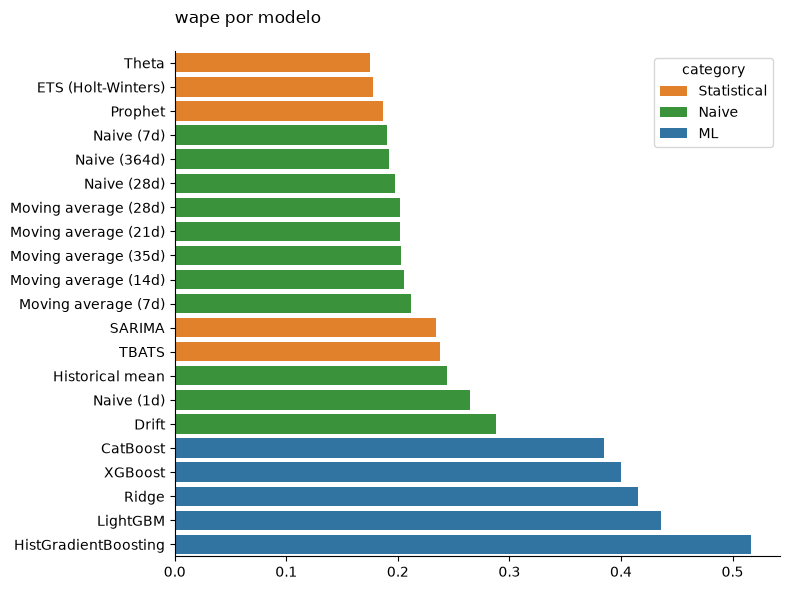

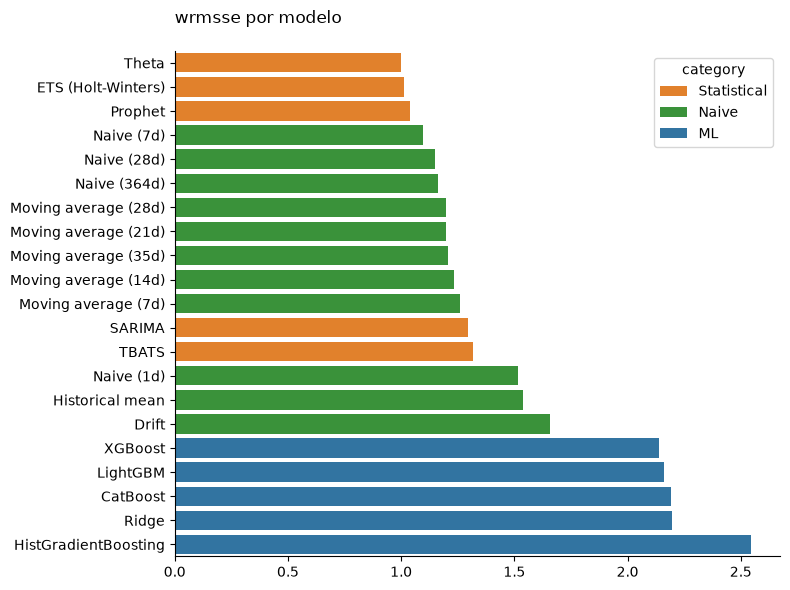

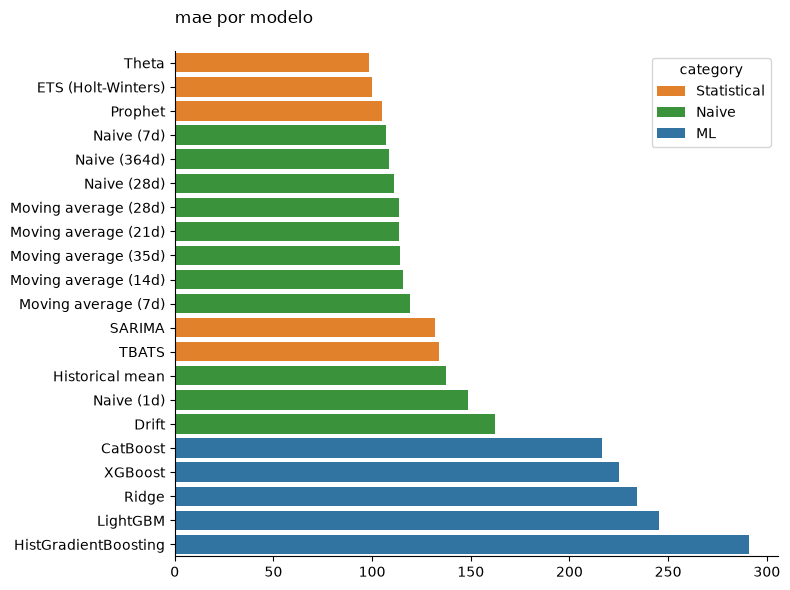

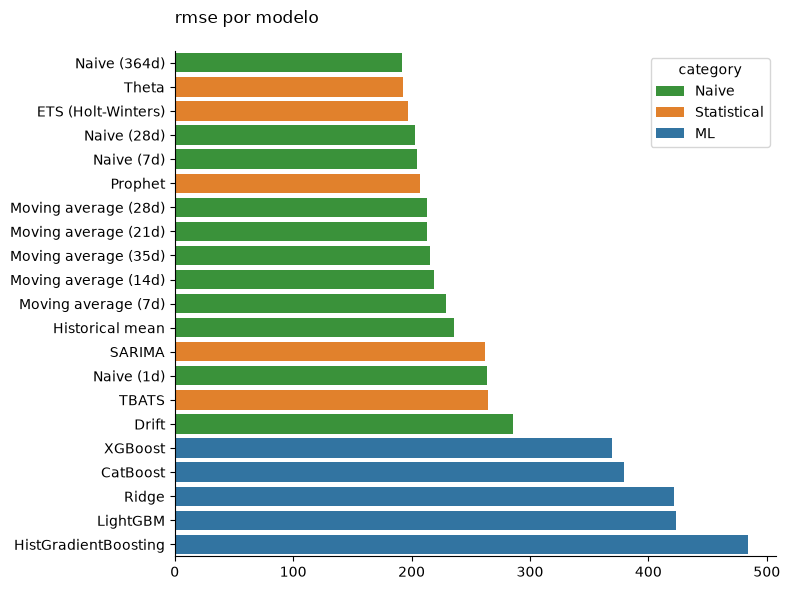

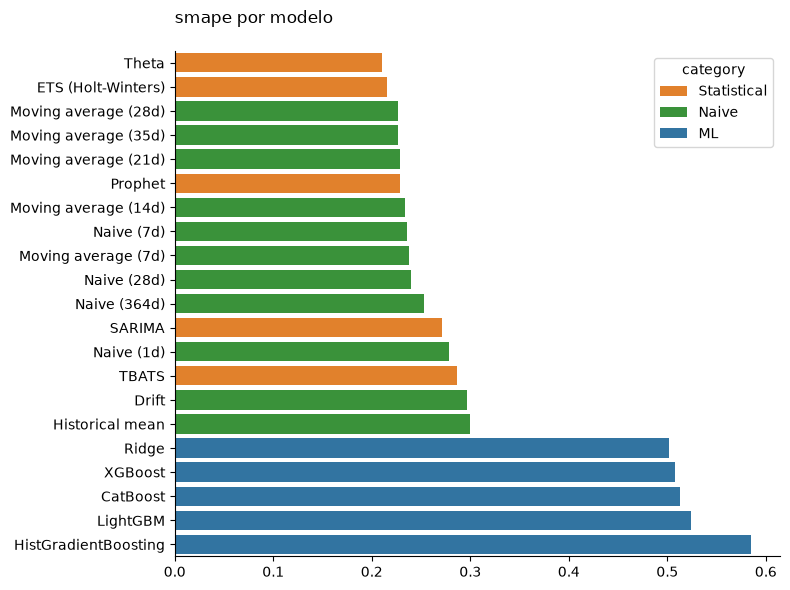

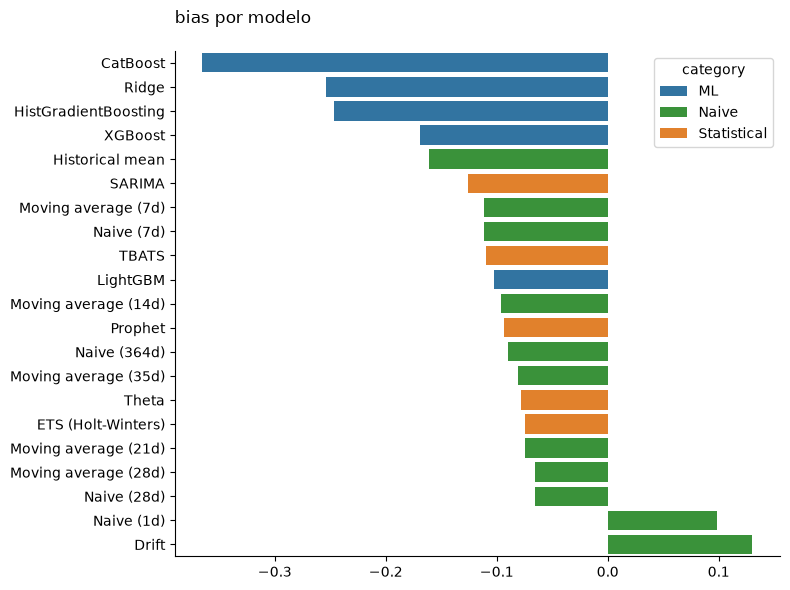

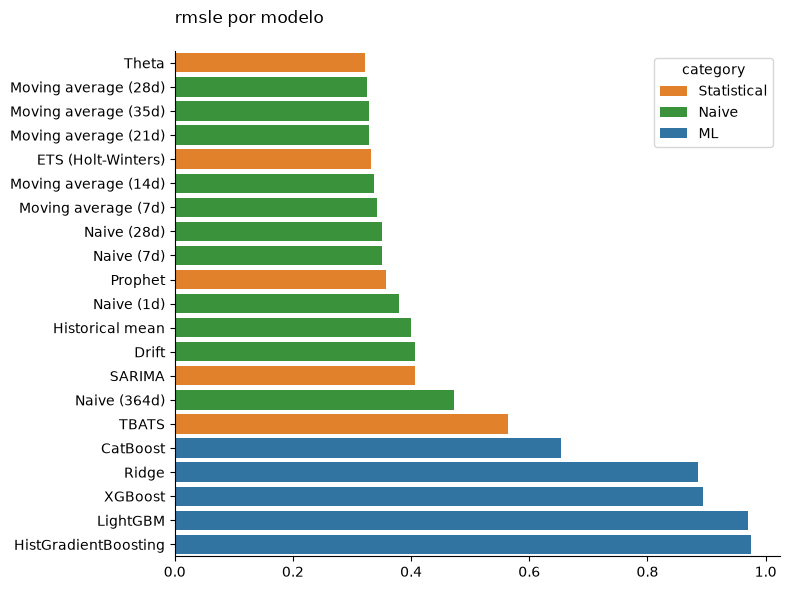

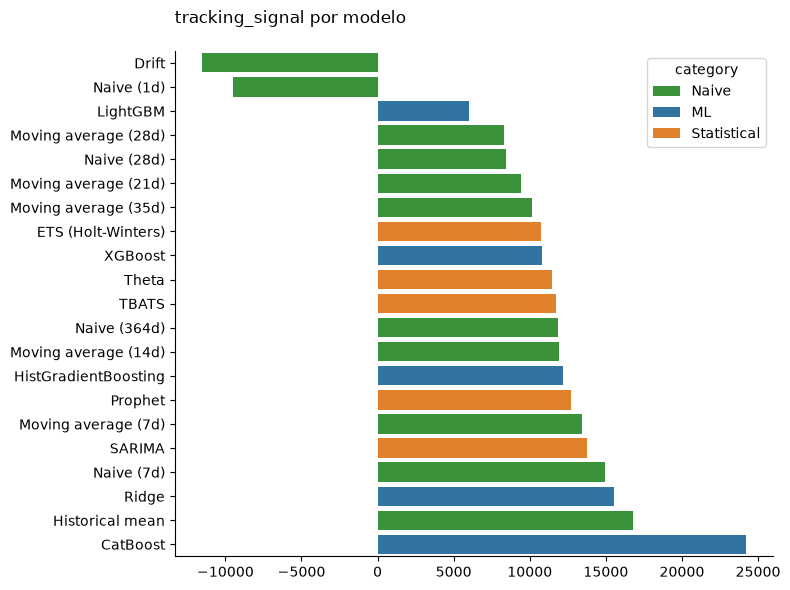

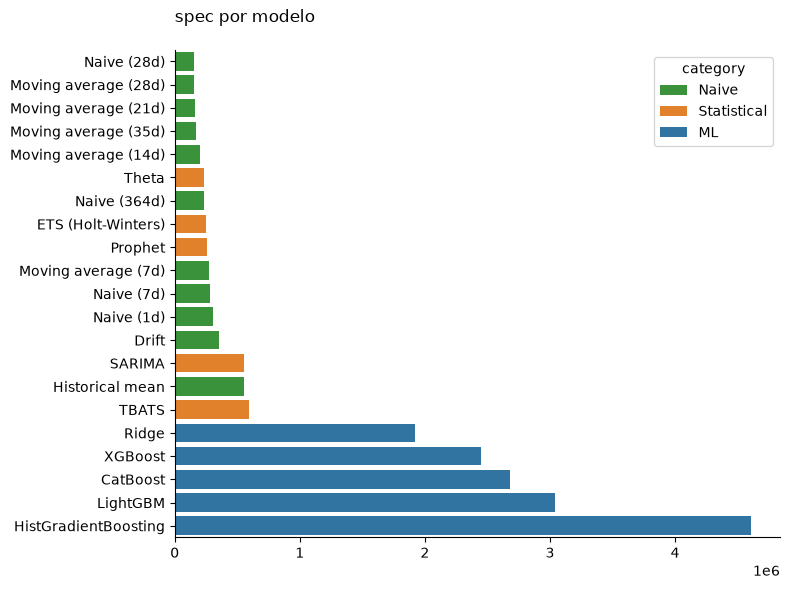

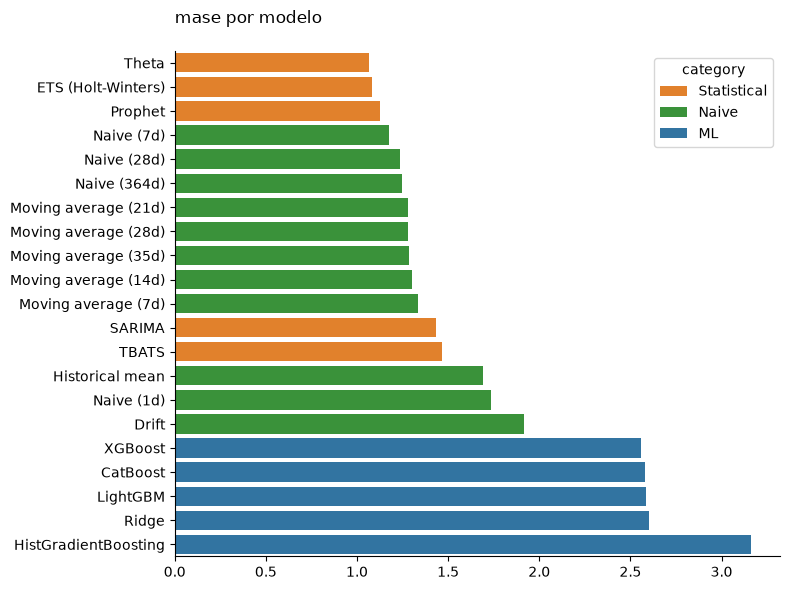

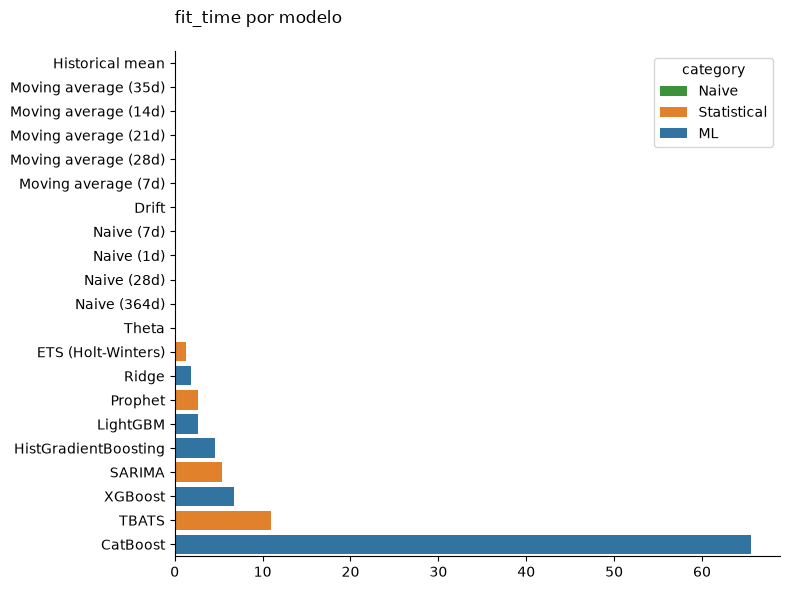

In [31]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

# Selección de features

El resto del notebook usa LightGBM (velocidad, soporte nativo de categóricas, compatible con SHAP), así que la selección se hace sobre `lgbm_model`. Se comparan dos criterios de importancia (gain del árbol vs. permutation importance sobre validación) y luego se aplica una eliminación hacia atrás (backward elimination): se van descartando las features menos importantes mientras el WRMSSE de validación no empeore más allá de una tolerancia.

## Importancia por ganancia (gain)

In [32]:
importance_gain = (
    pd.Series(lgbm_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)
importance_gain.head(20)

rolling_mean_lag1_window_size7    8.403588e+10
lag1                              5.533264e+10
lag7                              2.638400e+10
lag28                             2.339594e+10
lag6                              2.388815e+09
lag21                             1.887107e+09
lag14                             1.868433e+09
lag91                             1.455912e+09
snap                              7.929648e+08
dayofweek                         6.852868e+08
lag35                             4.241035e+08
lag182                            3.268881e+08
event_name_1                      2.965606e+08
is_store_closed                   2.924551e+08
lag13                             2.768431e+08
price_change                      2.261020e+08
lag364                            2.184809e+08
lag56                             1.723810e+08
dept_id                           1.556927e+08
price_vs_mean                     1.541630e+08
dtype: float64

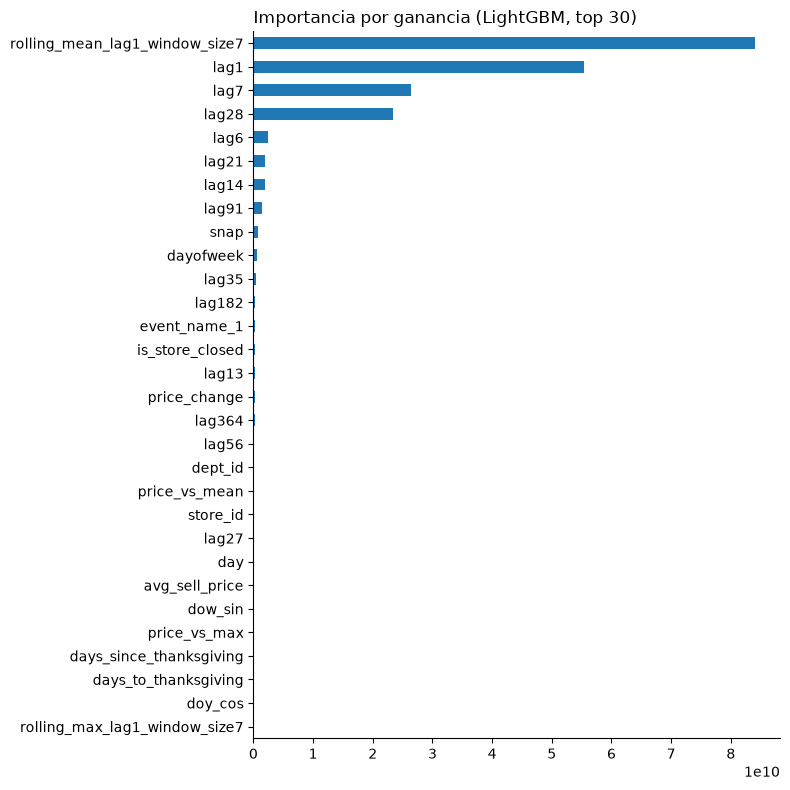

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_gain.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Importancia por ganancia (LightGBM, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Permutation importance

In [34]:
from src.modeling import compute_permutation_importance


importance_perm = compute_permutation_importance(
    lgbm_model, X_valid, y_valid, FEATURES,
    objective=OBJECTIVE, tweedie_variance_power=config.TWEEDIE_VARIANCE_POWER,
    sample_size=SAMPLE_SIZE_IMP_PERM, n_repeats=N_REPEATS_IMP_PERM, random_state=RANDOM_STATE,
)
importance_perm.head(20)

dept_id                            56.254753
lag28                              33.608372
lag182                             22.474573
lag364                             15.567112
lag7                               13.611161
lag91                              13.589241
lag14                               9.949328
lag56                               6.806331
lag21                               6.517071
lag1                                5.375297
dayofweek                           3.830407
expanding_mean_lag91                3.591116
lag13                               2.826468
lag6                                2.681837
snap                                2.334895
rolling_mean_lag28_window_size7     1.559692
dow_sin                             1.313914
rolling_min_lag28_window_size7      1.307332
store_id                            1.171078
lag22                               1.104356
dtype: float64

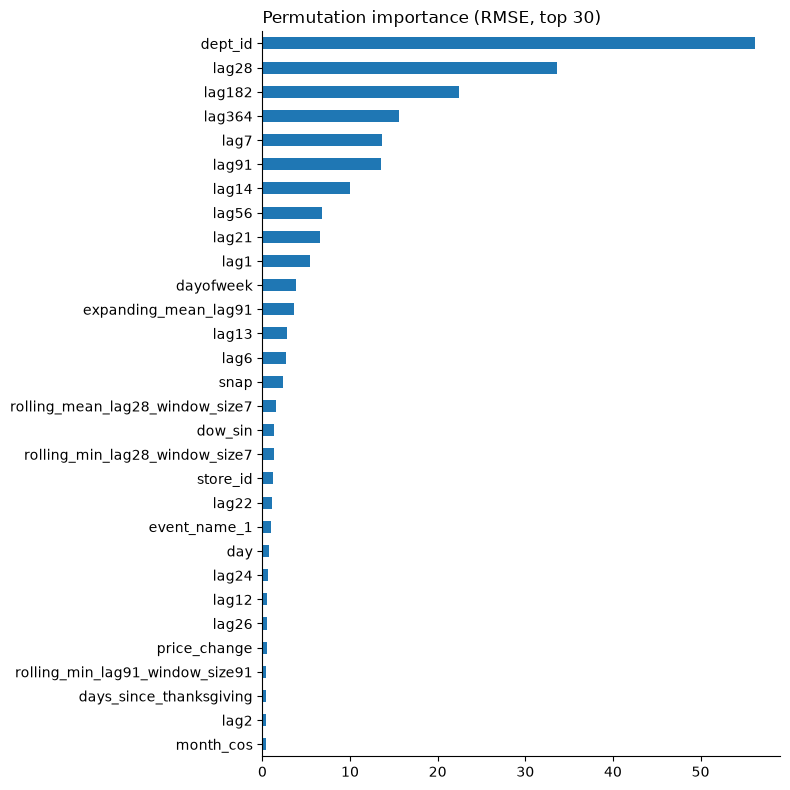

In [35]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_perm.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Permutation importance (RMSE, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Eliminación hacia atrás (backward elimination)

Se parte del ranking de permutation importance (de menor a mayor) y se intenta eliminar cada feature: si reentrenar sin ella no empeora el WRMSSE de validación más allá de `TOLERANCE`, se descarta definitivamente.

In [36]:
from src.modeling import backward_feature_selection

selected_features, final_score, final_wrmsse, log_df = backward_feature_selection(
    X_train, y_train, X_valid, y_valid, train, valid,
    FEATURES, CATEGORICAL_FEATURES, importance_perm,
    objective=OBJECTIVE, tweedie_variance_power=config.TWEEDIE_VARIANCE_POWER,
    tolerance=TOLERANCE_PERMUTATION, random_state=RANDOM_STATE,
)

2026-08-24 00:13:40.769 | INFO     | src.modeling.feature_selection:backward_feature_selection:101 - Baseline (173 features): rmse=422.9332 | WRMSSE=2.1599 (informativo)
2026-08-24 00:13:42.597 | WARNING  | src.modeling.feature_selection:backward_feature_selection:118 - ELIMINADA: 'price_vs_mean' -> 172 features | rmse=420.0158 | WRMSSE=2.1300
2026-08-24 00:13:44.535 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:120 - mantiene: 'lag35' | rmse empeoraría a 441.3133
2026-08-24 00:13:46.479 | WARNING  | src.modeling.feature_selection:backward_feature_selection:118 - ELIMINADA: 'rolling_std_lag28_window_size28' -> 171 features | rmse=419.2461 | WRMSSE=2.1042
2026-08-24 00:13:48.388 | WARNING  | src.modeling.feature_selection:backward_feature_selection:118 - ELIMINADA: 'price_vs_max' -> 170 features | rmse=406.1720 | WRMSSE=2.0220
2026-08-24 00:13:50.505 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:120 - mantiene: 'avg_sell_price' | rmse em

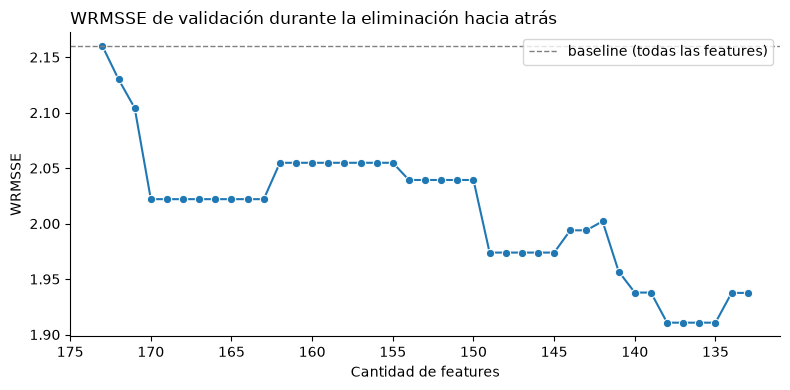

In [37]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

## Features seleccionadas

Se fija `FEATURES` (y las variables derivadas `X_train`/`X_valid`/`X_test`/`CATEGORICAL_FEATURES`/`NUMERICAL_FEATURES`) al subconjunto seleccionado, para que el resto del notebook (modelo simple, SHAP, tuning con Optuna, modelo final) entrene sobre las features filtradas.

In [38]:
print(f"Features descartadas ({len(FEATURES) - len(selected_features)}): "
      f"{sorted(set(FEATURES) - set(selected_features))}")

FEATURES = selected_features
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in FEATURES]
NUMERICAL_FEATURES = [c for c in NUMERICAL_FEATURES if c in FEATURES]

X_train = X_train[FEATURES]
X_valid = X_valid[FEATURES]
X_test = X_test[FEATURES]

print(f"Features finales: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categóricas)")

Features descartadas (40): ['adi_expanding', 'days_since_release', 'event_name_2', 'event_type_2', 'event_type_2_enc', 'has_event', 'has_event_2', 'is_likely_stockout', 'is_month_end', 'is_month_start', 'is_weekend', 'item_id', 'price_vs_max', 'price_vs_mean', 'quarter', 'rolling_max_lag2_window_size14', 'rolling_max_lag3_window_size7', 'rolling_max_lag4_window_size7', 'rolling_max_lag5_window_size14', 'rolling_max_lag6_window_size14', 'rolling_max_lag6_window_size7', 'rolling_max_lag7_window_size14', 'rolling_mean_lag1_window_size14', 'rolling_mean_lag1_window_size35', 'rolling_mean_lag28_window_size28', 'rolling_mean_lag28_window_size91', 'rolling_mean_lag3_window_size14', 'rolling_mean_lag4_window_size7', 'rolling_mean_lag5_window_size14', 'rolling_mean_lag5_window_size7', 'rolling_mean_lag6_window_size7', 'rolling_mean_lag7_window_size14', 'rolling_mean_lag7_window_size7', 'rolling_min_lag2_window_size14', 'rolling_min_lag7_window_size14', 'rolling_std_lag28_window_size28', 'rollin

# Modelo con variables seleccionadas

In [39]:
from src.evaluation import make_wrmsse_metric

wrmsse_metric = make_wrmsse_metric(train, valid)

In [40]:
model = LGBMRegressor(
    objective=OBJECTIVE,
)

t0 = time.perf_counter()
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=[wrmsse_metric,],
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features)", model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 100 rounds
[10]	valid_0's rmse: 562.011	valid_0's wrmsse: 2.99204
[20]	valid_0's rmse: 482.404	valid_0's wrmsse: 2.49235
[30]	valid_0's rmse: 449.343	valid_0's wrmsse: 2.29291
[40]	valid_0's rmse: 425.597	valid_0's wrmsse: 2.15513
[50]	valid_0's rmse: 413.852	valid_0's wrmsse: 2.10375
[60]	valid_0's rmse: 405.749	valid_0's wrmsse: 2.07831
[70]	valid_0's rmse: 399.066	valid_0's wrmsse: 2.0497
[80]	valid_0's rmse: 398.614	valid_0's wrmsse: 2.02427
[90]	valid_0's rmse: 389.282	valid_0's wrmsse: 1.99137


2026-08-24 00:30:09.495 | INFO     | src.evaluation.metrics:evaluate_predictions:359 - LightGBM (selected features) [ML] | WAPE: 38.53% | WRMSSE: 1.9375 | MAE: 216.928 | RMSE: 379.127 | SMAPE: 48.84% | Bias: -7.03% | RMSLE: 0.9079 | TS: 4651.59 | SPEC: 2356494.928 | MASE: 2.2843 | fit: 2.76s


[100]	valid_0's rmse: 379.275	valid_0's wrmsse: 1.93754
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 379.275	valid_0's wrmsse: 1.93754
Evaluated only: rmse


{'model': 'LightGBM (selected features)',
 'category': 'ML',
 'wape': 0.38529428321277254,
 'wrmsse': 1.9375439625021689,
 'mae': 216.9277885254436,
 'rmse': 379.1271641504763,
 'smape': 0.48838288937157326,
 'bias': -0.07033870074515973,
 'rmsle': 0.9079461316510253,
 'tracking_signal': 4651.587560661885,
 'spec': 2356494.9278907464,
 'mase': 2.284278693324353,
 'fit_time': 2.757602539997606}

## Explicación modelo

In [41]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(SAMPLE_SIZE_EXPLAINER, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                              feature  mean_abs_shap
33                               lag1      72.361726
60                              lag28      52.422310
39                               lag7      44.889096
67     rolling_mean_lag1_window_size7      33.330015
0                             dept_id      25.908238
..                                ...            ...
126  rolling_mean_lag91_window_size91       0.012222
100     rolling_max_lag5_window_size7       0.006166
105   rolling_mean_lag6_window_size14       0.005421
86    rolling_mean_lag2_window_size14       0.005014
97     rolling_max_lag4_window_size14       0.003223

[133 rows x 2 columns]


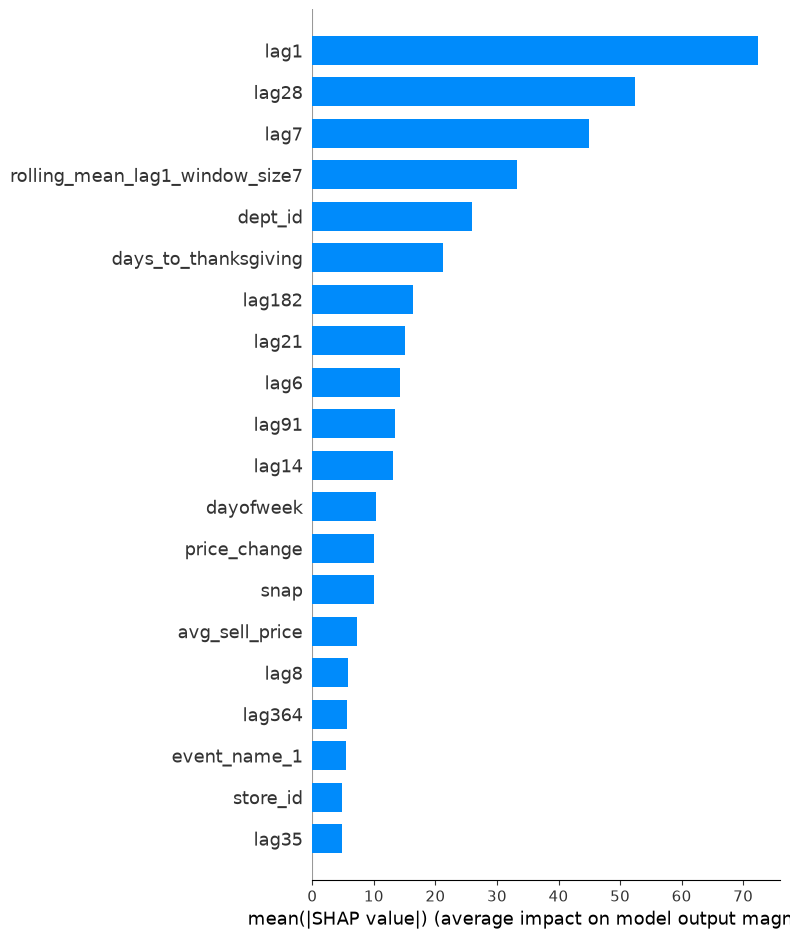

In [42]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


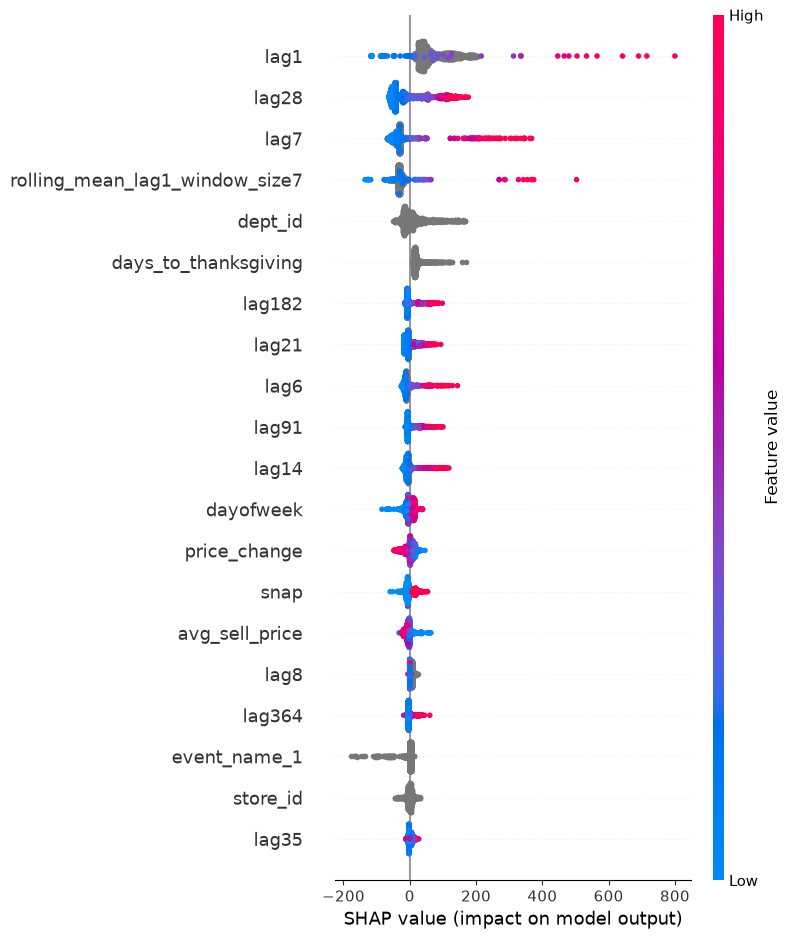

In [43]:
shap.summary_plot(shap_values, X_shap)

## Resultados

In [44]:
from src.evaluation import build_predictions_report

metrics_test, df_pred = build_predictions_report(train, test, y_test, model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test['wrmsse']:.4f}")

Test WAPE: 38.25%
Test WRMSSE: 2.0630


# Modelo optimizado

In [45]:
import optuna
from optuna.integration import LightGBMPruningCallback

from src.evaluation import objective_metric

In [46]:
def objective(trial):
    params = dict(
        objective=OBJECTIVE,
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        n_estimators=1500,
        num_leaves=trial.suggest_int("num_leaves", 31, 255),
        max_depth=trial.suggest_int("max_depth", 5, 10),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 5, log=True),
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    if OBJECTIVE == "tweedie":
        params["tweedie_variance_power"] = trial.suggest_float(
            "tweedie_variance_power", 1.1, 1.9
        )

    eval_metric = "tweedie" if OBJECTIVE == "tweedie" else "rmse"

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric=eval_metric,
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            lgb.early_stopping(30, first_metric_only=True, verbose=False),
            LightGBMPruningCallback(trial, eval_metric),
        ],
    )

    y_pred = model.predict(X_valid, num_iteration=model.best_iteration_)

    # Optuna decide por OBJECTIVE (coherente con el objective de LightGBM);
    # el WRMSSE se calcula y se guarda como user_attr solo para informar.
    tweedie_power = params.get("tweedie_variance_power", config.TWEEDIE_VARIANCE_POWER)
    score = objective_metric(y_valid, y_pred, OBJECTIVE, tweedie_power)
    _, final_wrmsse, _ = wrmsse_metric(y_valid, y_pred)
    trial.set_user_attr("wrmsse", final_wrmsse)
    return score

In [47]:
study = optuna.create_study(
    study_name=f"study_{LEVEL}", 
    direction="minimize",
    storage="sqlite:///../artifacts/optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=42,
    ),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=5),
)

study.optimize(
    objective,
    n_trials=100_000,
    timeout = TIEMPO_OPTUNA,
    show_progress_bar=True,
)

best_trial = study.best_trial
print(f"Mejor {OBJECTIVE}: {best_trial.value:.4f} (WRMSSE informativo: {best_trial.user_attrs['wrmsse']:.4f})")
print("Mejores hiperparámetros:", best_trial.params)

[I 2026-08-24 00:30:10,569] A new study created in RDB with name: study_level_09_daily_store_dept


  0%|          | 0/100000 [00:00<?, ?it/s]

[I 2026-08-24 00:30:17,548] Trial 0 finished with value: 460.32214739980367 and parameters: {'learning_rate': 0.054816785328198704, 'num_leaves': 244, 'max_depth': 9, 'min_child_samples': 128, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0016400214911202306, 'reg_lambda': 1.599409170128044}. Best is trial 0 with value: 460.32214739980367.
[I 2026-08-24 00:30:20,430] Trial 1 finished with value: 463.26698874418156 and parameters: {'learning_rate': 0.07893736353172352, 'num_leaves': 190, 'max_depth': 5, 'min_child_samples': 195, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.004705059281907645, 'reg_lambda': 0.004768785415482609}. Best is trial 0 with value: 460.32214739980367.
[I 2026-08-24 00:30:29,537] Trial 2 finished with value: 438.3662580839279 and parameters: {'learning_rate': 0.048952790869270256, 'num_leaves': 149, 'max_depth': 7, 'min_child_samples': 72, 'subsample': 0.8447411578889518, 'colsamp

In [48]:
model_params = best_trial.params


final_model = lgb.LGBMRegressor(
    objective=OBJECTIVE,
    n_estimators=FINAL_ESTIMATORS,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    subsample_freq=1,
    **model_params,
)

t0 = time.perf_counter()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=wrmsse_metric,
    categorical_feature=CATEGORICAL_FEATURES,
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features | Optuna)", final_model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 100 rounds
[10]	valid_0's rmse: 487.741	valid_0's wrmsse: 2.52065
[20]	valid_0's rmse: 407.877	valid_0's wrmsse: 1.99965
[30]	valid_0's rmse: 380.443	valid_0's wrmsse: 1.91481
[40]	valid_0's rmse: 372.244	valid_0's wrmsse: 1.96442
[50]	valid_0's rmse: 368.791	valid_0's wrmsse: 1.93373
[60]	valid_0's rmse: 367.758	valid_0's wrmsse: 1.92404
[70]	valid_0's rmse: 358.324	valid_0's wrmsse: 1.86492
[80]	valid_0's rmse: 347.621	valid_0's wrmsse: 1.81627
[90]	valid_0's rmse: 342.481	valid_0's wrmsse: 1.77808
[100]	valid_0's rmse: 339.495	valid_0's wrmsse: 1.77737
[110]	valid_0's rmse: 338.966	valid_0's wrmsse: 1.75139
[120]	valid_0's rmse: 337.072	valid_0's wrmsse: 1.74618
[130]	valid_0's rmse: 336.495	valid_0's wrmsse: 1.7578
[140]	valid_0's rmse: 333.392	valid_0's wrmsse: 1.74024
[150]	valid_0's rmse: 334.675	valid_0's wrmsse: 1.746
[160]	valid_0's rmse: 333.59	valid_0's wrmsse: 1.73971
[170]	valid_0's rmse: 330.023	valid_0's wrmsse: 1.73669

2026-08-24 00:33:23.311 | INFO     | src.evaluation.metrics:evaluate_predictions:359 - LightGBM (selected features | Optuna) [ML] | WAPE: 29.32% | WRMSSE: 1.6038 | MAE: 165.077 | RMSE: 292.102 | SMAPE: 40.52% | Bias: -1.36% | RMSLE: 0.7788 | TS: 1181.48 | SPEC: 1114983.575 | MASE: 1.7596 | fit: 11.80s


Early stopping, best iteration is:
[549]	valid_0's rmse: 292.596	valid_0's wrmsse: 1.60377
Evaluated only: rmse


{'model': 'LightGBM (selected features | Optuna)',
 'category': 'ML',
 'wape': 0.29320073519319173,
 'wrmsse': 1.6037709795500548,
 'mae': 165.0774222475794,
 'rmse': 292.1015496642361,
 'smape': 0.40515379244949884,
 'bias': -0.013595442472131972,
 'rmsle': 0.7787999730273887,
 'tracking_signal': 1181.4836479235626,
 'spec': 1114983.57457352,
 'mase': 1.7595544839220791,
 'fit_time': 11.799528892006492}

## Resultados finales

In [49]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
metrics_test_final, df_pred = build_predictions_report(train, test, y_test, final_model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 33.17%
Test WRMSSE: 1.8695


# Exportar

In [50]:
import joblib

feature_importance = (
    pd.Series(final_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)

artifact = {
    # modelo y datos de trabajo
    "level": LEVEL,
    "objective": OBJECTIVE,
    "model": final_model,
    "model_params": model_params,
    "metrics_results": results_df,
    "X_test": X_test,
    "y_test": y_test,
    "train": train,
    "test": test,
    # features y columnas
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numerical_features": NUMERICAL_FEATURES,
    "id_cols": ID_COLS,
    "leaky_cols": LEAKY_COLS,
    "target": TARGET,
    "feature_importance": feature_importance,
    # comparación de todos los modelos probados (validación)
    "model_results": model_results,
    "results_df": results_df,
    # metadatos
    "wape_valid": model_results[-1]["wape"],
    "wrmsse_valid": model_results[-1]["wrmsse"],
    "wape_test": metrics_test_final["wape"],
    "wrmsse_test": metrics_test_final["wrmsse"],
    "train_start": str(first_date.date()),
    "valid_start": str(valid_start.date()),
    "test_start": str(test_start.date()),
}

artifact_path = f"../artifacts/models/{LEVEL}_{TARGET}_artifact.pkl"
joblib.dump(artifact, artifact_path)
print(f"Artifact guardado en {artifact_path}")

Artifact guardado en ../artifacts/models/level_09_daily_store_dept_sales_artifact.pkl
